In [2]:
import pandas as pd
import numpy as np
import random as rn
import matplotlib.pyplot as plt

In [3]:
num_samples=10000

Defining a function to gather A, B, C, D, E to make a dataframe

In [4]:
def gather_data (A,B,C,D,E):
    """Gathers df columns"""
    df=pd.DataFrame([A,B,C,D,E])
    df.index=["A","B","C","D","E"]
    df=df.T
    return df

Defining a function to asign treatment values to the dataframe (either 0 (No) or 1 (Yes))

In [5]:
def treatment_causal_effects (df, c_a_t, c_d_t, c_e_t):
    """Calculates treatment values (0 or 1)"""
    
    np.random.seed(42)
    noise_t = np.random.normal(0, 0.1, num_samples)
    t = np.sum([noise_t] + [c_a_t*df["A"]] + [c_e_t*df["E"]] + [c_d_t*df["D"]], axis=0)

    t_bin = np.array([convert_to_binary(x) for x in t]).flatten()

    return t_bin

Defining a function to calculate outcome values

In [6]:
def outcome_causal_effects (df, c_t_o, c_a_o, c_e_o, c_b_o):
    """Calculates outcome values"""

    np.random.seed(42)
    noise_out = np.random.normal(0, 0.1, num_samples)
    out = np.sum([noise_out] + [c_t_o*df["Treatment"]] + [c_a_o*df["A"]] + [c_e_o*df["E"]] + [c_b_o*df["B"]*df["Treatment"]], axis=0)

    return out

In [7]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def convert_to_binary(x, stochastic=True):
    p = sigmoid(x)
    if stochastic:
        return np.random.choice([0, 1], 1, p=[1 - p, p])
    else:
        return int(p > 0.5)

In [8]:
savename = "test_data_6"

## Making continous data

Note: D is a binomial value

In [11]:
np.random.seed(42)
A = np.random.normal(-0.25, 1, num_samples)
B = np.random.normal(0.20, 1, num_samples)
C = np.random.normal(-0.69, 1, num_samples)

df_d=pd.read_csv("arrival_to_scan_time.csv")
klm=df_d["bin_edge"]
np.random.seed(42)
D=np.random.choice(klm,10000,p=df_d["height"])

E = np.random.normal(0.90, 1, num_samples)

df=gather_data(A,B,C,D,E)

c_a_t=0.80
c_e_t=0.70
c_d_t=1.20

df["Treatment"]=treatment_causal_effects(df, c_a_t, c_e_t, c_d_t)

c_t_o=1.5
c_a_o=0.80
c_e_o=0.85
c_b_o=0.75

df["Outcome"]=outcome_causal_effects(df, c_t_o, c_a_o, c_e_o, c_b_o)

df

,A,B,C,D,E,Treatment,Outcome
0,0.246714,-0.478495,-0.341714,15.0,-0.587862,1,0.888489
1,-0.388264,-0.105499,-0.406676,120.0,-0.225186,1,0.905029
2,0.397689,-0.397381,-1.626520,30.0,1.288819,1,2.680380
3,1.273030,0.310418,-0.110416,15.0,-0.273873,1,2.670748
4,-0.484153,1.397179,-2.180083,0.0,2.012634,1,3.847885
...,...,...,...,...,...,...,...
9995,1.051102,0.587827,-1.267288,60.0,0.871876,1,3.652957
9996,-2.248345,1.577367,0.754604,75.0,1.692395,1,2.123050
9997,-0.955317,0.578354,-1.191367,120.0,1.894518,1,2.709321
9998,0.245766,1.913530,-2.582357,15.0,0.202670,1,3.353606


In [12]:
df.to_csv(f"continous_{savename}.csv", index=False)

## Making all binomial data

In [8]:
np.random.seed(42)

A = np.random.binomial(1, 0.25, num_samples)
B = np.random.binomial(1, 0.20, num_samples)
C = np.random.binomial(1, 0.69, num_samples)
D = np.random.binomial(1, 0.73, num_samples)
E = np.random.binomial(1, 0.90, num_samples)

df=gather_data(A,B,C,D,E)

c_a_t=0.45
c_e_t=0.15
c_d_t=1.32

df["Treatment"]=treatment_causal_effects(df, c_a_t, c_e_t, c_d_t)

c_t_o=5
c_a_o=0.33
c_e_o=0.39
c_b_o=0.02

df["Outcome"]=outcome_causal_effects(df, c_t_o, c_a_o, c_e_o, c_b_o)

df["Outcome"] = np.array([convert_to_binary(x) for x in df["Outcome"]]).flatten()

df

,A,B,C,D,E,Treatment,Outcome
0,0,0,0,1,1,1,1
1,1,0,1,1,1,0,0
2,0,0,1,0,1,0,0
3,0,0,1,1,1,0,0
4,0,0,1,1,1,1,1
...,...,...,...,...,...,...,...
9995,1,1,0,0,1,1,1
9996,1,0,0,0,1,1,1
9997,1,0,1,1,1,1,1
9998,0,0,1,1,1,1,1


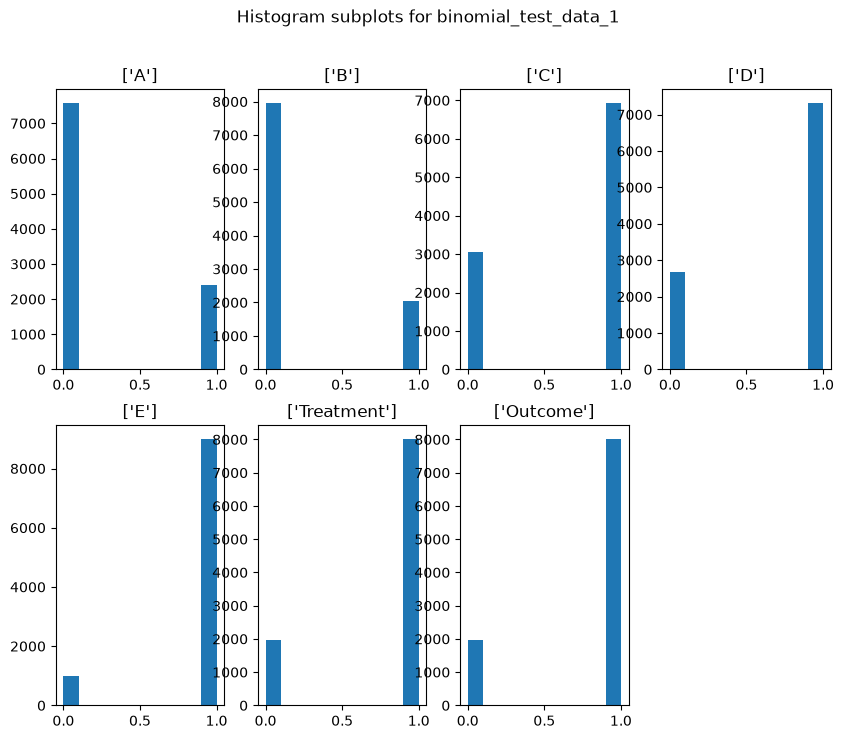

In [9]:
n_rows = 2
n_cols = 4
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i, a in enumerate(df.columns):

    # # To fill each column in turn: col = i // n_rows
    # To fill each row in turn: row = i % n_rows
    row = i // n_cols
    col = i % n_cols

    #print(row, col)

    axs[row,col].hist(df[a])
    axs[row,col].set_title(f"{[a]}")

# Make remaining subplots blank:
i += 1
while i < n_rows*n_cols:
    # Make sure this matches definition of row and col above.
    row = i // n_cols
    col = i % n_cols
    axs[row, col].set_visible(False)
    i += 1

plt.suptitle("Histogram subplots for binomial_test_data_1 ")

#import os
#directory ="Subplots"
#file_name=f"reference_{savename}.png"
#file_path = os.path.join(directory, file_name)
#plt.savefig(file_path)
plt.show()


In [50]:
df.to_csv(f"binomial_{savename}.csv", index=False)

## Making all binomial data except outcome

In [10]:
np.random.seed(42)

A = np.random.binomial(1, 0.25, num_samples)
B = np.random.binomial(1, 0.20, num_samples)
C = np.random.binomial(1, 0.69, num_samples)
D = np.random.binomial(1, 0.73, num_samples)
E = np.random.binomial(1, 0.90, num_samples)

df=gather_data(A,B,C,D,E)

c_a_t=0.80
c_e_t=0.70
c_d_t=1.20

df["Treatment"]=treatment_causal_effects(df, c_a_t, c_e_t, c_d_t)

c_t_o=1.5
c_a_o=0.80
c_e_o=0.85
c_b_o=0.75

df["Outcome"]=outcome_causal_effects(df, c_t_o, c_a_o, c_e_o, c_b_o)

df

,A,B,C,D,E,Treatment,Outcome
0,0,0,0,1,1,1,2.399671
1,1,0,1,1,1,1,3.136174
2,0,0,1,0,1,0,0.914769
3,0,0,1,1,1,0,1.002303
4,0,0,1,1,1,1,2.326585
...,...,...,...,...,...,...,...
9995,1,1,0,0,1,1,4.030110
9996,1,0,0,0,1,1,2.950166
9997,1,0,1,1,1,1,3.079468
9998,0,0,1,1,1,1,2.399577


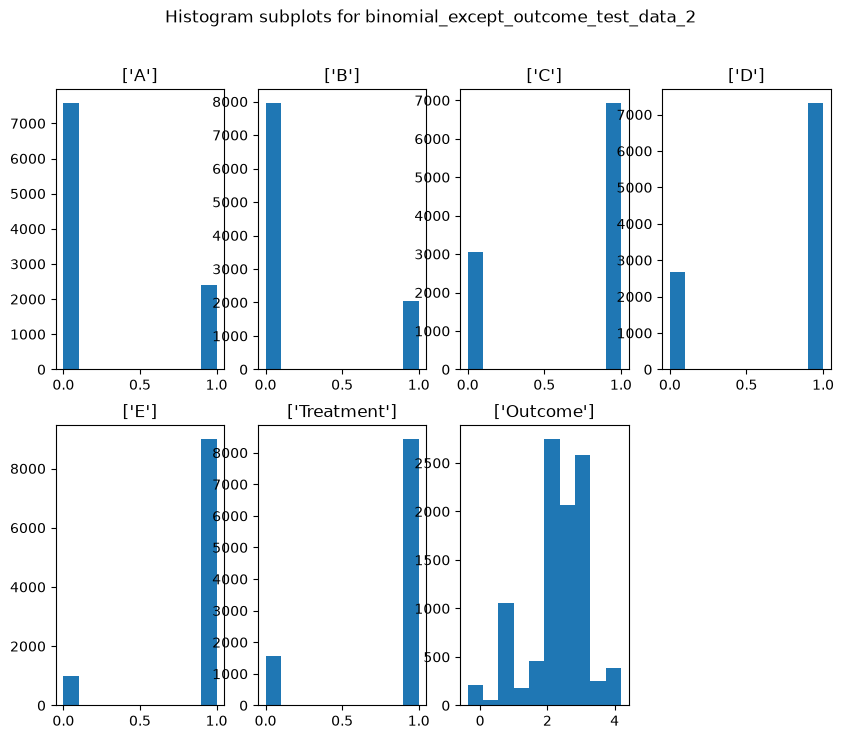

In [12]:
n_rows = 2
n_cols = 4
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i, a in enumerate(df.columns):

    # # To fill each column in turn: col = i // n_rows
    # To fill each row in turn: row = i % n_rows
    row = i // n_cols
    col = i % n_cols

    #print(row, col)

    axs[row,col].hist(df[a])
    axs[row,col].set_title(f"{[a]}")

# Make remaining subplots blank:
i += 1
while i < n_rows*n_cols:
    # Make sure this matches definition of row and col above.
    row = i // n_cols
    col = i % n_cols
    axs[row, col].set_visible(False)
    i += 1

plt.suptitle("Histogram subplots for binomial_except_outcome_test_data_2")

#import os
#directory ="Subplots"
##file_name=f"reference_{savename}.png"
#file_path = os.path.join(directory, file_name)
#plt.savefig(file_path)
plt.show()

In [ ]:
#df.to_csv(f"binomial_except_outcome_test_data_2.csv", index=False)